In [1]:
# notebooks/02_model_training.ipynb  OR  src/models/train.py

from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define directory paths
BASE_DIR = Path(__file__).resolve().parent.parent if "__file__" in locals() else Path("..")
DATA_PATH = BASE_DIR / "data" / "Telco-Customer-Churn.csv"
MODEL_DIR = BASE_DIR / "src" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# ---------------------------------------------------------
# Step 0: Load and Clean Data
# ---------------------------------------------------------
df = pd.read_csv(DATA_PATH)

# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

# Target variable (Churn: Yes=1, No=0)
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

# Identify numerical and categorical columns
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [col for col in X.columns if col not in num_cols]

In [3]:

# ---------------------------------------------------------
# Step 1: Preprocessing Setup (Encoding & Scaling)
# ---------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols),
    ]
)

In [4]:
# ---------------------------------------------------------
# Step 2: Train / Test Split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit preprocessor on training data and transform train/test
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Get feature names after OneHotEncoding for feature importance analysis
cat_feature_names = list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
)
feature_names = num_cols + cat_feature_names

In [5]:
# ---------------------------------------------------------
# Step 3 & 4: Train Baseline (Logistic Regression) & Random Forest
# ---------------------------------------------------------
log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

log_reg.fit(X_train_prep, y_train)
rf_clf.fit(X_train_prep, y_train)

RandomForestClassifier(random_state=42)


================ LOGISTIC REGRESSION EVALUATION ================
Accuracy : 0.8062
Precision: 0.6593
Recall   : 0.5588

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



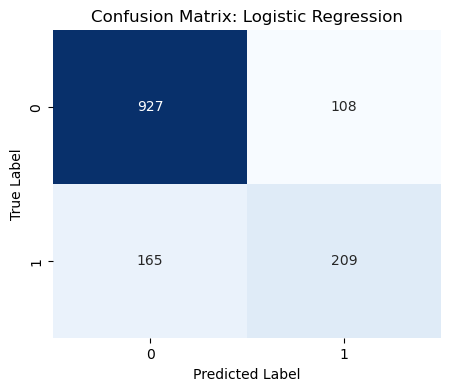


================ RANDOM FOREST EVALUATION ================
Accuracy : 0.7921
Precision: 0.6421
Recall   : 0.4893

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



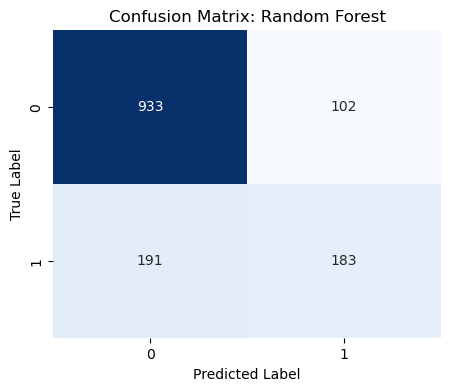


--- MODEL COMPARISON SUMMARY ---
                     Accuracy  Precision    Recall
Logistic Regression  0.806246   0.659306  0.558824
Random Forest        0.792051   0.642105  0.489305


In [6]:
# ---------------------------------------------------------
# Step 5: Evaluate Both Models
# ---------------------------------------------------------
models = {"Logistic Regression": log_reg, "Random Forest": rf_clf}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_prep)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec}

    print(f"\n================ {name.upper()} EVALUATION ================")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}\n")
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# Print Comparison DataFrame
results_df = pd.DataFrame(results).T
print("\n--- MODEL COMPARISON SUMMARY ---")
print(results_df)


--- TOP 10 FEATURES DRIVING CHURN (Random Forest) ---
                           Feature  Importance
2                     TotalCharges    0.192229
0                           tenure    0.174901
1                   MonthlyCharges    0.170283
28  PaymentMethod_Electronic check    0.041393
10     InternetService_Fiber optic    0.037420
3                      gender_Male    0.028275
25               Contract_Two year    0.028245
26            PaperlessBilling_Yes    0.026477
13              OnlineSecurity_Yes    0.025586
5                      Partner_Yes    0.023151


/tmp/ipykernel_22329/4152777194.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


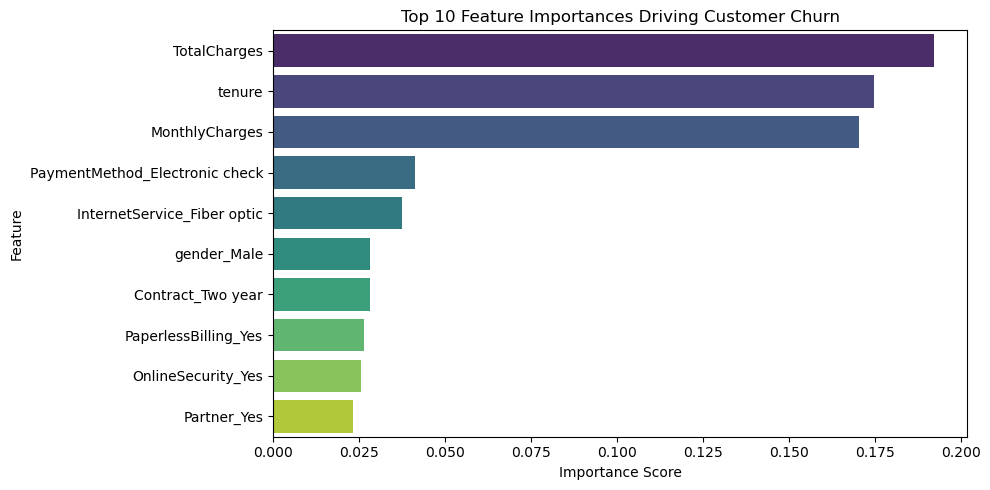

In [7]:
# ---------------------------------------------------------
# Step 6: Extract Top Features Driving Churn
# ---------------------------------------------------------
# Top features from Random Forest Feature Importances
importances = rf_clf.feature_importances_
feature_imp_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
).sort_values(by="Importance", ascending=False)

print("\n--- TOP 10 FEATURES DRIVING CHURN (Random Forest) ---")
print(feature_imp_df.head(10))

# Plot Top 10 Feature Importances
plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_imp_df.head(10), x="Importance", y="Feature", palette="viridis"
)
plt.title("Top 10 Feature Importances Driving Customer Churn")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [8]:
# ---------------------------------------------------------
# Step 7: Save Best Model & Preprocessor with Joblib
# ---------------------------------------------------------
# Select best model based on higher recall / F1 performance
best_model = log_reg if results["Logistic Regression"]["Recall"] > results["Random Forest"]["Recall"] else rf_clf
best_model_name = "logistic_regression" if best_model == log_reg else "random_forest"

# Save Preprocessor and Model into src/models/
joblib.dump(preprocessor, MODEL_DIR / "preprocessor.joblib")
joblib.dump(best_model, MODEL_DIR / f"best_model_{best_model_name}.joblib")

print(f"\nSuccessfully saved preprocessor and {best_model_name} model to '{MODEL_DIR}'!")


Successfully saved preprocessor and logistic_regression model to '../src/models'!
